## Making imports

In [533]:
import pandas as pd
import matplotlib.pyplot as plt

## Reading the files and loading them

In [534]:
def load_df():
    hourly_df = pd.read_csv('BTCUSDT-klines-1h-2026-01-01_2026-07-16.csv')
    four_hourly_df = pd.read_csv('BTCUSDT-klines-4h-2026-01-01_2026-07-16.csv')
    return hourly_df, four_hourly_df

### Preparing Notifications

In [535]:
class NotificationLevel:
    INFO = "INFO"
    WARNING = "WARNING"
    ERROR = "ERROR"

class NotificationEvent:
    BUY_SIGNAL = "BUY"
    SELL_SIGNAL = "SELL"
    TRADE_LOG = "TRADE_LOG"
    DROPDOWN_ALERT = "DROPDOWN_ALERT"

In [536]:
hourly_df, four_hourly_df = load_df()

## Data Understanding and Analysis

In [537]:
hourly_df.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2026-01-01 00:00:00,87648.21,87849.26,87632.74,87809.23,233.66036,2026-01-01 00:59:59,2.050795e+07,44782,150.35907,1.319677e+07,0
1,2026-01-01 01:00:00,87809.24,88050.00,87809.23,87960.00,241.44162,2026-01-01 01:59:59,2.123116e+07,63768,142.20649,1.250447e+07,0
2,2026-01-01 02:00:00,87960.01,88088.10,87895.37,87914.00,209.55860,2026-01-01 02:59:59,1.843628e+07,59893,107.33226,9.443168e+06,0
3,2026-01-01 03:00:00,87914.00,88015.70,87832.09,87846.02,149.08354,2026-01-01 03:59:59,1.310830e+07,46780,68.74735,6.045057e+06,0
4,2026-01-01 04:00:00,87846.01,87854.81,87550.43,87590.40,476.17901,2026-01-01 04:59:59,4.172514e+07,93385,200.12394,1.753489e+07,0


In [538]:
four_hourly_df.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2026-01-01 00:00:00,87648.21,88088.10,87632.74,87846.02,833.74412,2026-01-01 03:59:59,7.328369e+07,215223,468.64517,4.118947e+07,0
1,2026-01-01 04:00:00,87846.01,87854.81,87550.43,87631.88,1108.52485,2026-01-01 07:59:59,9.716147e+07,194935,510.38550,4.473387e+07,0
2,2026-01-01 08:00:00,87631.88,88024.64,87631.87,88024.64,819.82493,2026-01-01 11:59:59,7.201011e+07,177638,368.39485,3.235303e+07,0
3,2026-01-01 12:00:00,88024.64,88113.45,87810.66,88032.18,1005.89204,2026-01-01 15:59:59,8.846925e+07,251384,517.36184,4.549984e+07,0
4,2026-01-01 16:00:00,88032.17,88500.00,87879.03,88391.15,1140.33499,2026-01-01 19:59:59,1.005942e+08,326168,548.99644,4.843044e+07,0


In [539]:
# Total count of rows in the hourly dataframe
hourly_count = len(hourly_df)
hourly_count

4728

In [540]:
four_hourly_count = len(four_hourly_df)
four_hourly_count

1182

In [541]:
hourly_df.columns

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_volume', 'trades', 'taker_buy_base_volume',
       'taker_buy_quote_volume', 'ignore'],
      dtype='str')

### Viewing the overall trend of bitcoin trades

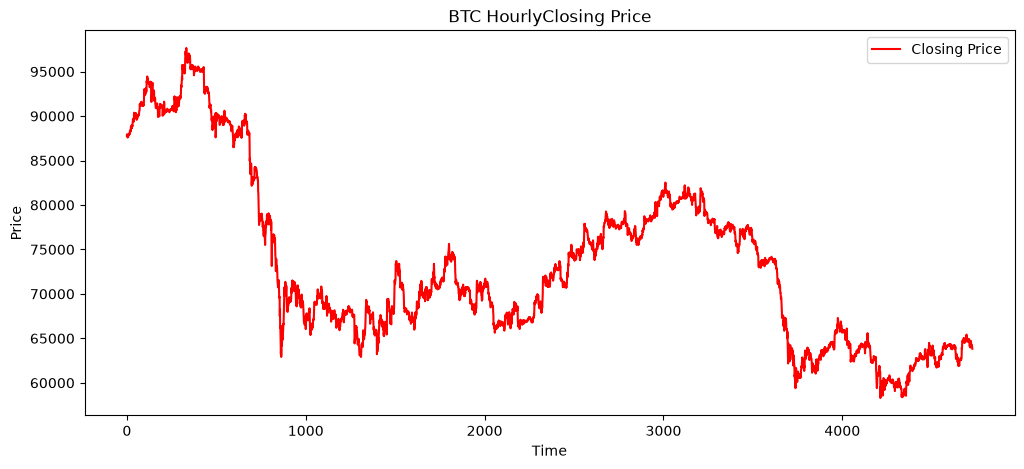

In [542]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(hourly_df["close"], label="Closing Price", color="red")
plt.title("BTC HourlyClosing Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

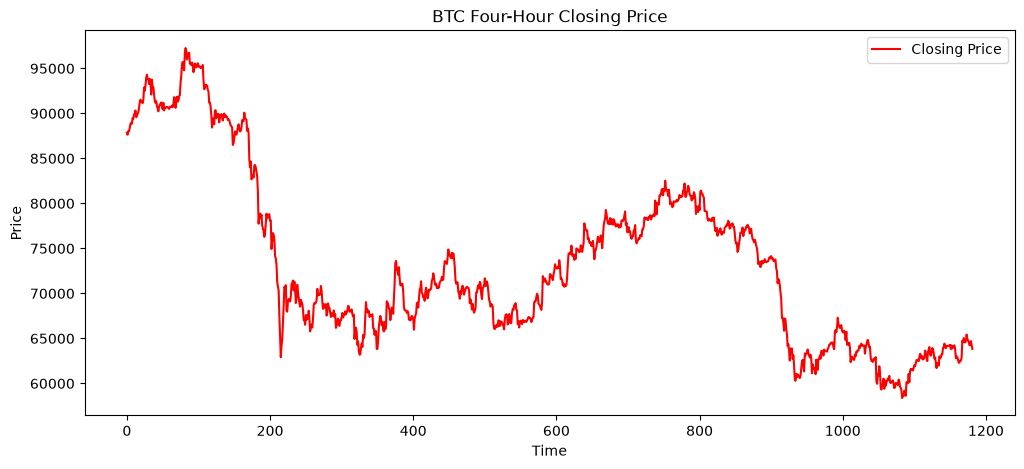

In [543]:
plt.figure(figsize=(12, 5))
plt.plot(four_hourly_df["close"], label="Closing Price", color="red")
plt.title("BTC Four-Hour Closing Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Assumptions & Constants

- Initial capital: 10,000 USDT
- Position size: 100% of available capital
- No leverage
- No transaction fees
- Trades execute at the candle close after a signal is generated

In [544]:
CAPITAL = 10_000  # Starting capital in USDT
RISK_FREE_RATE_PER_PERIOD = 0 # Assume our risk-free rate is 0 for simplicity, as we are not considering interest earned on cash holdings in this backtest.
DRAWDOWN_THRESHOLD = -0.15

### Getting the first opening and final closing to calculate buy and hold baseline value

In [545]:
opening_price = hourly_df.iloc[0]["close"]
closing_price = hourly_df.iloc[-1]["close"]

base_line_profit = closing_price - opening_price

base_line_result = (closing_price - opening_price) / opening_price * 100
base_line_result

np.float64(-27.308097337831118)

### Postions

In [546]:
BUY = 1
HOLD = 0
SELL = -1

## Functions

In [547]:
def drop_unnecessary_columns(df: pd.DataFrame) -> pd.DataFrame:
    # These columns are not needed for our analysis, so we can drop them to simplify the dataframe.
    df.drop(columns=['quote_volume', 'trades', 'taker_buy_base_volume',
       'taker_buy_quote_volume', 'ignore'], inplace=True)
    return df

In [548]:
def calculate_moving_averages(df: pd.DataFrame, fast_ma: float, slow_ma: float) -> pd.DataFrame:
    df["ma_fast"] = df["close"].rolling(fast_ma).mean()
    df["ma_slow"] = df["close"].rolling(slow_ma).mean()
    df["diff"] = df["close"] - df["open"]
    return df

In [549]:
def generate_signals(df):
    # Creating a new column to indicate buy signals where position 1 
    # indicates a buy signal and -1 indicates a sell signal and 0 represents flat
    # First drop all rows where either moving average is NaN to avoid errors in comparison
    df = df.dropna(subset=["ma_fast", "ma_slow"]).copy()

    df["signal"] = 0

    buy_mask = (df["ma_fast"] > df["ma_slow"]) & (
        df["ma_fast"].shift(1) <= df["ma_slow"].shift(1)
    )

    sell_mask = (df["ma_fast"] < df["ma_slow"]) & (
        df["ma_fast"].shift(1) >= df["ma_slow"].shift(1)
    )

    df.loc[buy_mask, "signal"] = 1
    df.loc[sell_mask, "signal"] = -1

    return df

In [ ]:
from src.notification import emit_notification


def generate_trade_log(df: pd.DataFrame, notifications: list) -> pd.DataFrame:
    """
    Simulate the moving average crossover strategy over historical price data.

    Iterates through each candle, executes trades based on generated buy and
    sell signals, records completed trades, updates the current market position,
    and send notifications for trading events.
    """

    position = 0  # 0 means no position (holding cash), 1 means holding a position (holding BTC)
    entry_price = 0
    trade_log = []
    candle_stick_held_for = (
        0  # Counter for how many candlesticks the position has been held
    )
    for index, row in df.iterrows():
        if row["signal"] == 1 and position == 0:
            position = 1
            entry_price = row["close"]
            entry_time = row["close_time"]
            emit_notification(
                notifications,
                event=NotificationEvent.BUY_SIGNAL,
                severity=NotificationLevel.INFO,
                message="Buy signal generated",
                entry_price=entry_price,
                entry_time=entry_time,
            )
        elif position == 1 and row["signal"] == -1:
            position = 0
            exit_price = row["close"]
            exit_time = row["close_time"]
            profit = exit_price - entry_price
            trade_return = (exit_price - entry_price) / entry_price
            emit_notification(
                notifications,
                event=NotificationEvent.SELL_SIGNAL,
                severity=NotificationLevel.INFO,
                message="Sell signal generated",
                exit_price=exit_price,
                exit_time=exit_time,
                profit=profit,
                return_percentage=trade_return * 100,
            )
            trade_log.append(
                {
                    "index": index,
                    "entry_time": entry_time,
                    "exit_time": exit_time,
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "profit": profit,
                    "return": trade_return * 100,  # Convert to percentage
                    "candle_sticks_held": candle_stick_held_for,
                }
            )
            emit_notification(
                notifications,
                event=NotificationEvent.TRADE_LOG,
                severity=NotificationLevel.INFO,
                message="Trade completed",
                entry_time=entry_time,
                exit_time=exit_time,
                profit=profit,
                return_percentage=trade_return * 100,
                candle_sticks_held=candle_stick_held_for,
            )
        df.loc[index, "position"] = position
        candle_stick_held_for = candle_stick_held_for + 1 if position == 1 else 0
    return pd.DataFrame(trade_log)

In [ ]:
def generate_metrics(df: pd.DataFrame, notifications: list) -> pd.DataFrame:

    df["market_return"] = df["close"].pct_change().fillna(0)

    df["buy_hold_equity"] = CAPITAL * (1 + df["market_return"]).cumprod()

    df["strategy_return"] = (
        df["position"].shift(1).fillna(0) * df["market_return"]
    )  # Whether we made money or not while in position. If we were in position, we take the market return, otherwise we take 0.
    df["equity"] = CAPITAL * (1 + df["strategy_return"]).cumprod()

    strategy_return = df["equity"].iloc[-1] / df["equity"].iloc[0] - 1 # Return gained with the new strategy

    buy_hold_return = df["buy_hold_equity"].iloc[-1] / df["buy_hold_equity"].iloc[0] - 1 # Return gained with the buy hold strategy

    df["running_max"] = df["equity"].cummax() # The highest value seen up to each position.

    df["drawdown"] = (df["equity"] - df["running_max"]) / df["running_max"]

    previous = df["drawdown"].shift(1)

    breach = (previous > DRAWDOWN_THRESHOLD) & (df["drawdown"] <= DRAWDOWN_THRESHOLD)

    for _, row in df.loc[breach].iterrows():
        emit_notification(
            notifications,
            event=NotificationEvent.DROPDOWN_ALERT,
            severity=NotificationLevel.WARNING,
            message=f"Drawdown reached {row['drawdown']:.2%}.",
            time=row["close_time"],
            drawdown=row["drawdown"],
        )

    return df, strategy_return, buy_hold_return

In [ ]:
import numpy as np


def calculate_metrics(
    df: pd.DataFrame, trade_log_df: pd.DataFrame, periods_per_year: int
) -> tuple:
    """
    Calculate the key performance metrics for the backtested strategy.

    Computes the strategy's maximum drawdown, annualized Sharpe ratio,
    total number of completed trades, and win rate based on the generated
    equity curve and trade log.
    """
    drawdown = df["drawdown"].min()
    returns = df["strategy_return"].dropna()
    sharpe = (returns.mean() - RISK_FREE_RATE_PER_PERIOD) / returns.std()
    annualized_sharpe = sharpe * np.sqrt(periods_per_year)
    number_of_trades = len(trade_log_df)
    win_rate = (trade_log_df["return"] > 0).mean()

    return drawdown, annualized_sharpe, number_of_trades, win_rate

## Graphs

In [553]:
def plot_equity_curve(df: pd.DataFrame) -> None:
    print("Plotting equity curve...")
    plt.figure(figsize=(12, 5))
    plt.plot(df["equity"], label="Strategy Equity", color="blue")
    plt.plot(df["buy_hold_equity"], label="Buy & Hold Equity", color="orange")
    plt.title("Equity Curve Comparison")
    plt.xlabel("Time")
    plt.ylabel("Equity (USDT)")
    plt.legend()
    plt.show()

In [ ]:
def plot_signals(df: pd.DataFrame) -> None:
    # Graph that shows the buy and sell signals
    print("Plotting signals...")
    plt.figure(figsize=(12, 5))

    plt.plot(df["close_time"], df["close"], label="BTC Close")
    plt.plot(df["close_time"], df["ma_fast"], label="MA 20")
    plt.plot(df["close_time"], df["ma_slow"], label="MA 50")

    plt.scatter(
        df.loc[df["signal"] == 1, "close_time"],
        df.loc[df["signal"] == 1, "close"],
        marker="^",
        s=80,
        label="Buy"
    )

    plt.scatter(
        df.loc[df["signal"] == -1, "close_time"],
        df.loc[df["signal"] == -1, "close"],
        marker="v",
        s=80,
        label="Sell"
    )
    plt.title("Trading Signals on BTC Price")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

In [ ]:
def plot_equity_comparison(df: pd.DataFrame) -> None:
    # Graph that compares the equity between the moving average strategy and the buy hold strategy
    print("Plotting equity comparison...")
    plt.figure(figsize=(16,8))

    plt.plot(
        df["close_time"],
        df["equity"],
        label="Moving Average Strategy"
    )

    plt.plot(
        df["close_time"],
        df["buy_hold_equity"],
        label="Buy & Hold"
    )
    plt.title("Equity Comparison: Moving Average Strategy vs Buy & Hold")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

In [ ]:
def plot_drawdown(df: pd.DataFrame) -> None:
    # Drawdown shows the peak-to-trough decline in a trading account's equity
    print("Plotting drawdown...")
    plt.figure(figsize=(16,5))

    plt.plot(
            df["close_time"],
            df["drawdown"] * 100
    )

    plt.title("Drawdown Over Time")
    plt.xlabel("Time")
    plt.ylabel("% Drawdown")
    plt.show()

In [ ]:
def plot_trade_returns(trade_log_df: pd.DataFrame) -> None:
    # Shows the return per trade we get
    print("Plotting trade returns...")
    plt.figure(figsize=(14,5))

    plt.bar(
        trade_log_df.index,
        trade_log_df["return"]
    )
    plt.xlabel("Trade Number")
    plt.ylabel("Return (%)")
    plt.title("Returns per Trade")
    plt.show()

In [ ]:
def plot_graphs(df: pd.DataFrame, trade_log_df: pd.DataFrame) -> None:
    print("Plotting all graphs...")
    print()
    # plot_equity_curve(df)
    plot_signals(df)
    plot_equity_comparison(df)
    plot_drawdown(df)
    plot_trade_returns(trade_log_df)

In [559]:
def run_backtest(df: pd.DataFrame, periods_per_year: int, portfolio: float = None, fast_ma: float = None, slow_ma: float = None, show_graphs: bool = False) -> None:
    """Simulate the moving-average crossover strategy and return
    the updated DataFrame, trade log, and performance metrics."""
    notifications = []
    if portfolio:
        global CAPITAL
        CAPITAL = portfolio
    if slow_ma is None:
        slow_ma = 50
    if fast_ma is None:
        fast_ma = 20
    df = drop_unnecessary_columns(df)
    df = calculate_moving_averages(df, fast_ma, slow_ma)
    df = generate_signals(df)
    trade_log_df = generate_trade_log(df, notifications)
    df, strategy_return, buy_hold_return = generate_metrics(df, notifications)
    drawdown, sharpe, number_of_trades, win_rate = calculate_metrics(df, trade_log_df, periods_per_year)

    print(f"Drawdown: {drawdown:.2%}")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Number of Trades: {number_of_trades}")
    print(f"Win Rate: {win_rate:.2%}")

    if show_graphs:
        plot_graphs(df, trade_log_df)
    return {"df": df, "trade_log_df": trade_log_df, "notifications": notifications, "drawdown": drawdown, "sharpe": sharpe, "number_of_trades": number_of_trades, "win_rate": win_rate, "strategy_return": strategy_return, "buy_hold_return": buy_hold_return}

Running Back Test Analysis for Hourly Data...
Drawdown: -11.72%
Sharpe Ratio: 0.12
Number of Trades: 45
Win Rate: 37.78%
Plotting all graphs...

Plotting signals...


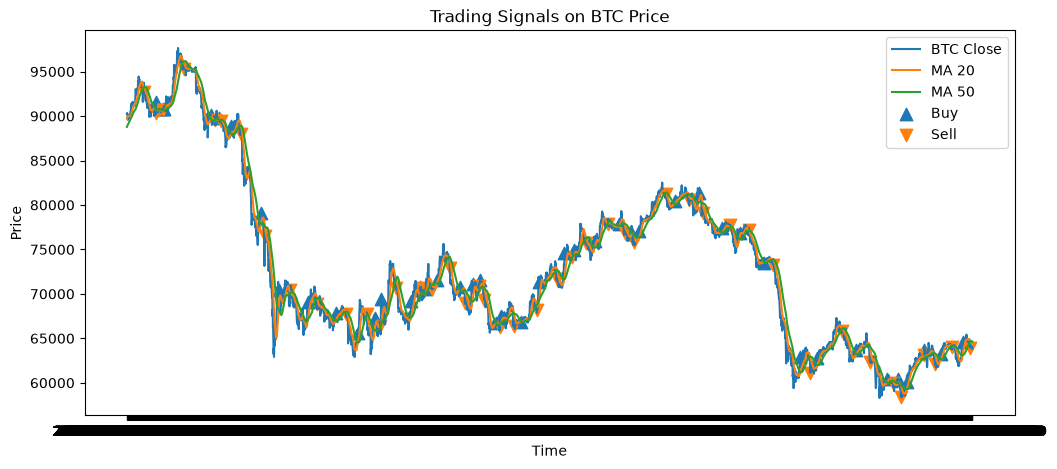

Plotting equity comparison...


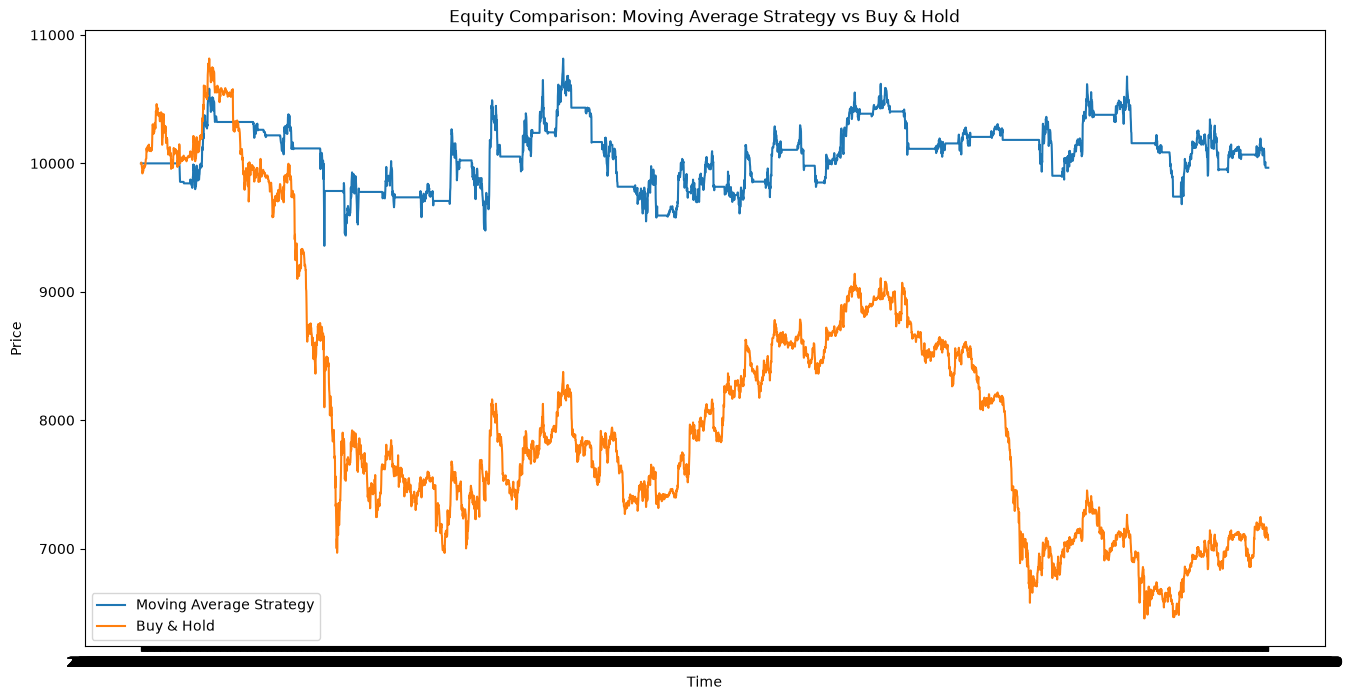

Plotting drawdown...


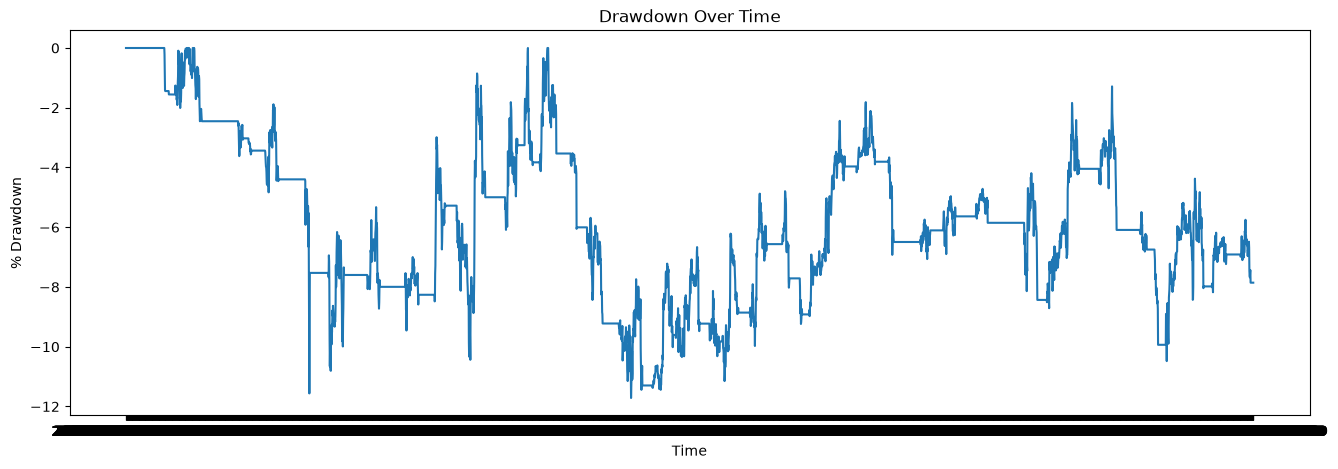

Plotting trade returns...


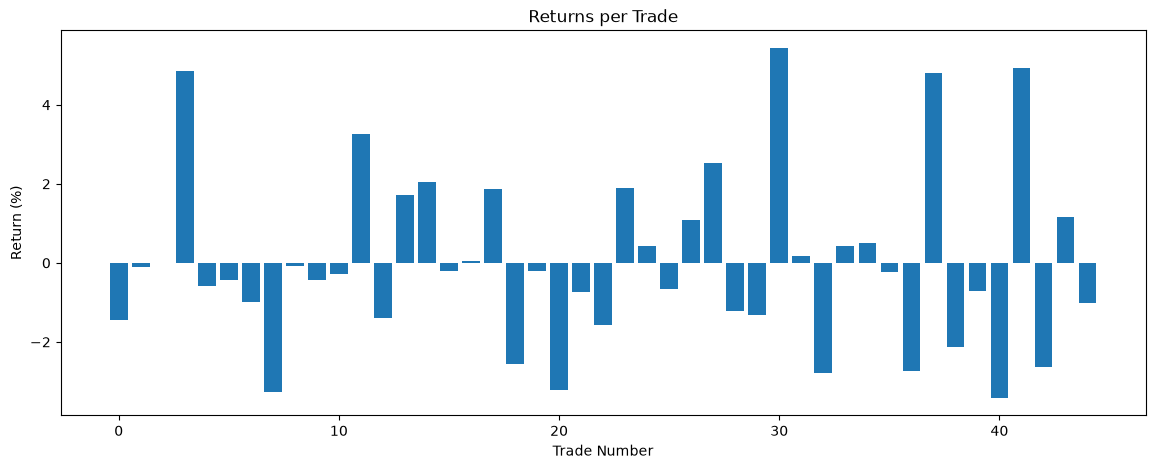




Running Back Test Analysis for Four-Hourly Data...
Drawdown: -19.65%
Sharpe Ratio: -0.26
Number of Trades: 11
Win Rate: 45.45%
Plotting all graphs...

Plotting signals...


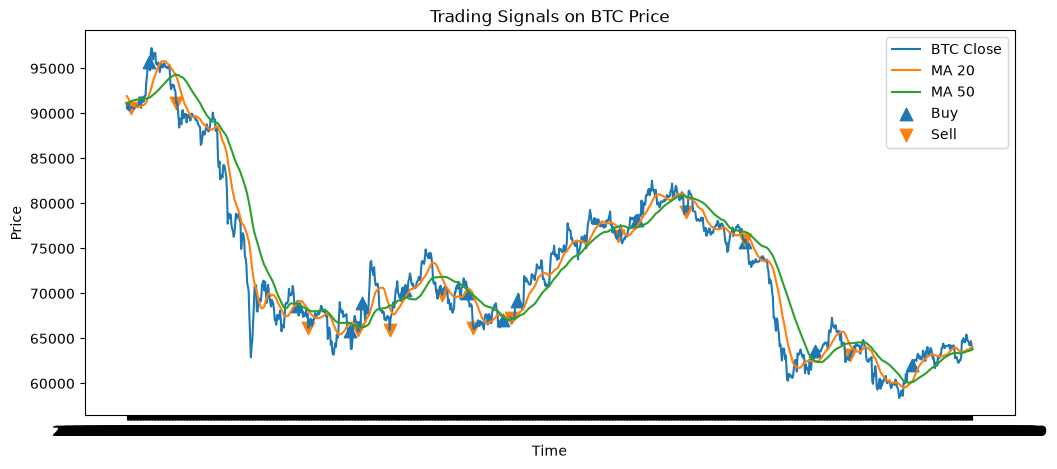

Plotting equity comparison...


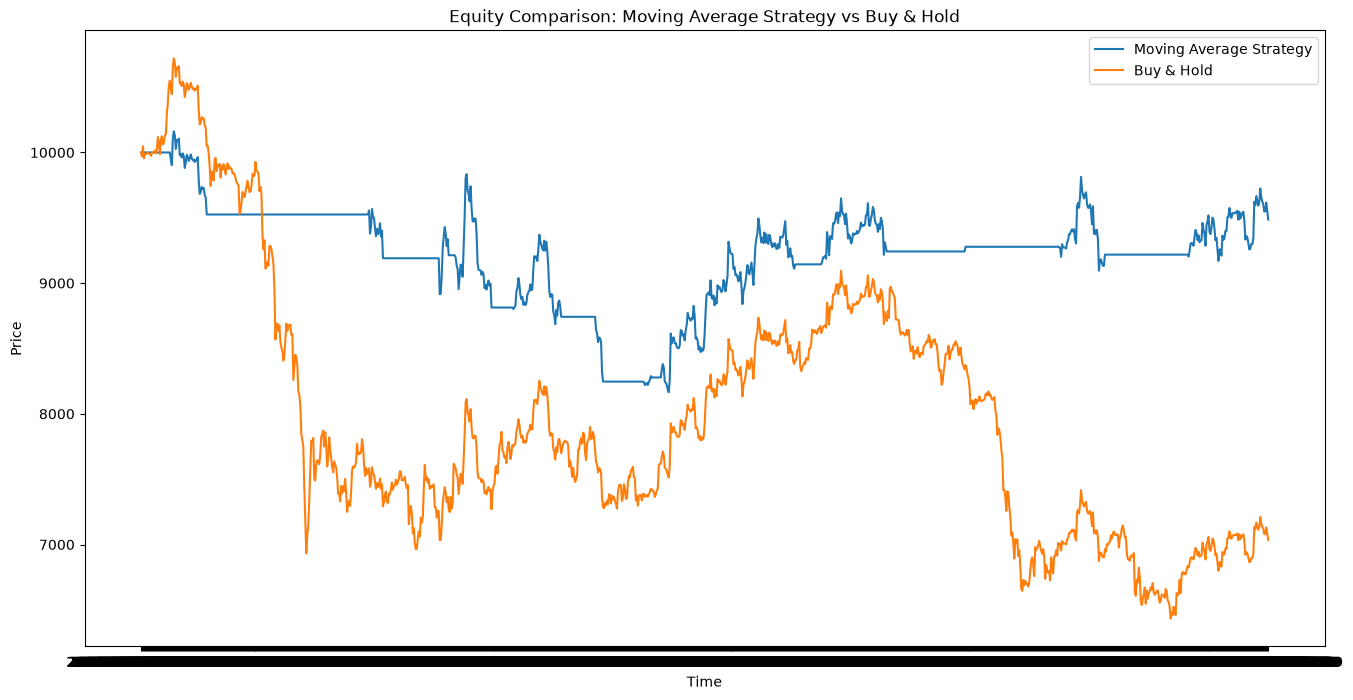

Plotting drawdown...


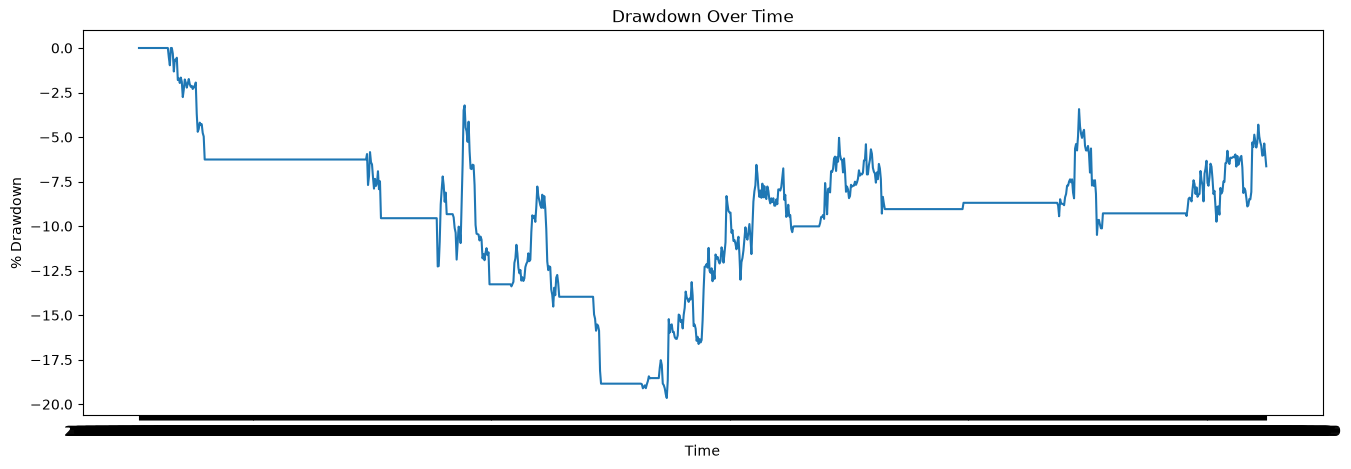

Plotting trade returns...


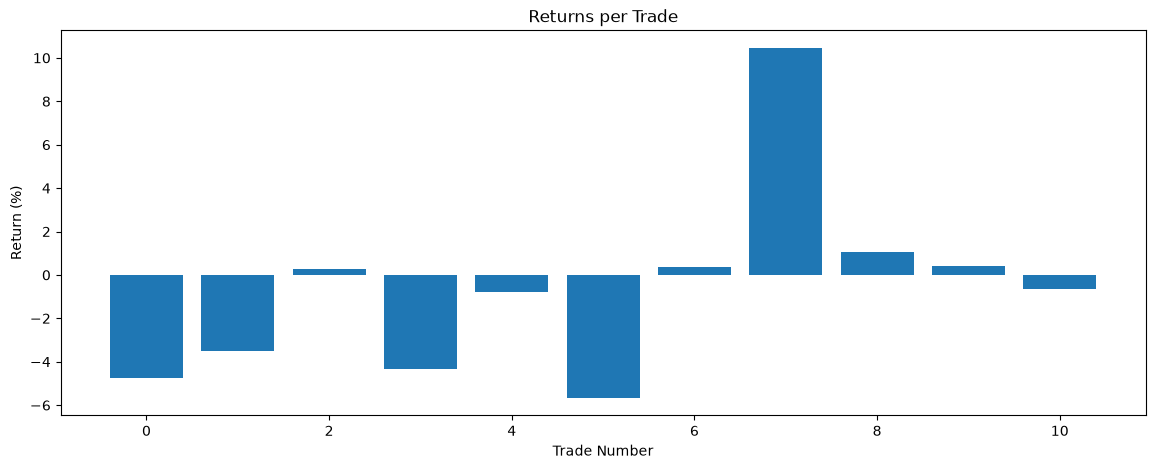

In [560]:
hourly_df, four_hourly_df = load_df()
HOURLY_PERIODS_PER_YEAR = 24 * 365  # 8760
FOUR_HOURLY_PERIODS_PER_YEAR = 6 * 365  # 2190

print("Running Back Test Analysis for Hourly Data...")
hourly_results = run_backtest(hourly_df, HOURLY_PERIODS_PER_YEAR, portfolio=10_000, fast_ma=20, slow_ma=50,show_graphs=True)

print()
print()
print()

print("Running Back Test Analysis for Four-Hourly Data...")
four_hourly_results = run_backtest(four_hourly_df, FOUR_HOURLY_PERIODS_PER_YEAR, portfolio=10_000, fast_ma=20, slow_ma=50,show_graphs=True)

In [561]:
def comparison(hourly_metrics: tuple, four_hourly_metrics: tuple) -> None:
    print("Comparison of Hourly vs Four-Hourly Backtest Results:")
    print()
    print(f"{'Metric':<25}{'Hourly':<15}{'Four-Hourly':<15}")
    print("-" * 55)
    print(f"{'Drawdown':<25}{hourly_metrics['drawdown']:<15.2%}{four_hourly_metrics['drawdown']:<15.2%}")
    print(f"{'Sharpe Ratio':<25}{hourly_metrics['sharpe']:<15.2f}{four_hourly_metrics['sharpe']:<15.2f}")
    print(f"{'Number of Trades':<25}{hourly_metrics['number_of_trades']:<15}{four_hourly_metrics['number_of_trades']:<15}")
    print(f"{'Win Rate':<25}{hourly_metrics['win_rate']:<15.2%}{four_hourly_metrics['win_rate']:<15.2%}")
    print(f"{'Strategy Return':<25}{hourly_metrics['strategy_return']:<15.2%}{four_hourly_metrics['strategy_return']:<15.2%}")
    print(f"{'Buy-Hold Return':<25}{hourly_metrics['buy_hold_return']:<15.2%}{four_hourly_metrics['buy_hold_return']:<15.2%}")

In [562]:
len(hourly_results)

9

In [563]:
comparison(hourly_results, four_hourly_results)

Comparison of Hourly vs Four-Hourly Backtest Results:

Metric                   Hourly         Four-Hourly    
-------------------------------------------------------
Drawdown                 -11.72%        -19.65%        
Sharpe Ratio             0.12           -0.26          
Number of Trades         45             11             
Win Rate                 37.78%         45.45%         
Strategy Return          -0.34%         -5.13%         
Buy-Hold Return          -29.30%        -29.66%        


## Results explanation

- Drawdown:	Hourly strategy experienced a smaller worst loss.
- Sharpe:	Hourly had a slightly positive risk-adjusted return; 4-hour strategy had negative average returns. Consistent with the total return.

- Trades: 4-hour data has fewer candles and therefore fewer crossovers.

- Win Rate:	A higher win rate does not necessarily mean higher profitability.
- Strategy Return: Hourly lost only a little, 4-hour lost more.
- Buy & Hold:	These should be almost identical because they're based on the same underlying market. A 0.36% difference is likely due to the datasets starting/ending on slightly different timestamps.

In [564]:
def store_trade_log_to_csv(trade_log, file_path):
    df = pd.DataFrame(trade_log)
    df.to_csv(file_path, index=False, mode="w")

# Storing Trade Logs to CSV files for both hourly and four-hourly results
store_trade_log_to_csv(hourly_results['trade_log_df'], "hourly_trade_log.csv")
store_trade_log_to_csv(four_hourly_results['trade_log_df'], "four_hourly_trade_log.csv")

In [565]:
from src.notification import store_notifications_to_csv

# Storing Notifications to CSV files for both hourly and four-hourly results
store_notifications_to_csv(hourly_results['notifications'], "hourly_notifications.csv")
store_notifications_to_csv(four_hourly_results['notifications'], "four_hourly_notifications.csv")

### Executive Summary
- The moving-average crossover strategy outperformed a passive buy-and-hold investment during the evaluation period by reducing losses.
- The hourly strategy produced 45 trades, offering more opportunities but requiring more active management.
- The 4-hour strategy traded less frequently (11 trades) but produced a lower risk-adjusted performance in this dataset.